# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO 
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence.

<img src="./assets/bricks.jpg">

# Import Statements

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Exploration

How many different colours does the LEGO company produce?

In [4]:
colors = pd.read_csv('./data/colors.csv')
print(colors.head())

   id            name     rgb is_trans
0  -1         Unknown  0033B2        f
1   0           Black  05131D        f
2   1            Blue  0055BF        f
3   2           Green  237841        f
4   3  Dark Turquoise  008F9B        f


In [14]:
colors['name'].nunique()

135

Find the number of transparent colours versus the number of opaque colors

In [5]:
transparent_colors = colors[colors['is_trans'] == 't'].shape[0]
print(transparent_colors)

28


In [6]:
opaque_colors = colors[colors['is_trans'] == 'f'].shape[0]
print(opaque_colors)

107


<h3>Understanding LEGO Themes vs. LEGO Sets</h3>

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.
<img src="./assets/lego_themes.png">

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

<img src="./assets/lego_sets.png">

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

In [7]:
sets = pd.read_csv('./data/sets.csv')

In [22]:
print(sets.head())

  set_num                        name  year  theme_id  num_parts
0   001-1                       Gears  1965         1         43
1  0011-2           Town Mini-Figures  1978        84         12
2  0011-3  Castle 2 for 1 Bonus Offer  1987       199          0
3  0012-1          Space Mini-Figures  1979       143         12
4  0013-1          Space Mini-Figures  1979       143         12


In [23]:
print(sets.tail())

           set_num                                 name  year  theme_id  \
15705      wwgp1-1  Wild West Limited Edition Gift Pack  1996       476   
15706   XMASTREE-1                       Christmas Tree  2019       410   
15707      XWING-1                  Mini X-Wing Fighter  2019       158   
15708      XWING-2                    X-Wing Trench Run  2019       158   
15709  YODACHRON-1      Yoda Chronicles Promotional Set  2013       158   

       num_parts  
15705          0  
15706         26  
15707         60  
15708         52  
15709        413  


In which year were the first LEGO sets released and what were these sets called?

In [28]:
sets.sort_values(by='year').head()


,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


How many different sets did LEGO sell in their first year? How many types of LEGO products were on offer in the year the company started?

In [30]:
print(sets[sets['year'] == 1949])

      set_num                               name  year  theme_id  num_parts
9521  700.1-1         Extra-Large Gift Set (ABB)  1949       365        142
9534  700.2-1               Large Gift Set (ABB)  1949       365        178
9539  700.3-1              Medium Gift Set (ABB)  1949       365        142
9544  700.A-1              Small Brick Set (ABB)  1949       371         24
9545  700.B-1  Small Doors and Windows Set (ABB)  1949       371         12


Find the top 5 LEGO sets with the most number of parts. 

In [5]:
print(sets.sort_values(by='num_parts', ascending=False).head())

        set_num                           name  year  theme_id  num_parts
15004  BIGBOX-1  The Ultimate Battle for Chima  2015       571       9987
11183   75192-1          UCS Millennium Falcon  2017       171       7541
10551   71043-1                Hogwarts Castle  2018       246       6020
295     10256-1                      Taj Mahal  2017       673       5923
221     10189-1                      Taj Mahal  2008       673       5922


Show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019? 

In [10]:
sets_by_year = sets.groupby('year').count()['set_num']
sets_by_year.head() # 1955: 28 sets, 2019: 840 sets

year
1949     5
1950     6
1953     4
1954    14
1955    28
Name: set_num, dtype: int64

In [9]:
sets_by_year.tail()

year
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, dtype: int64

Show the number of LEGO releases on a line chart using Matplotlib.

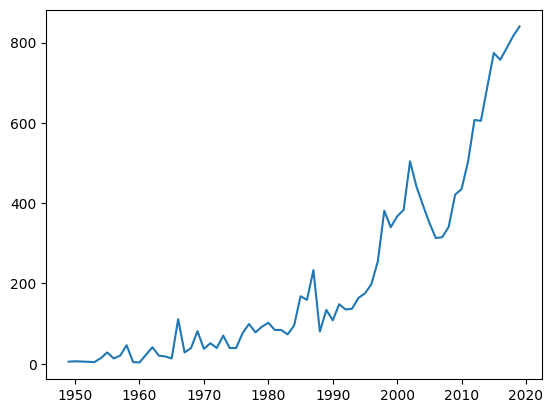

In [10]:
plt.plot(sets_by_year[:-2])

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [55]:
themes_per_year = sets.groupby('year').agg({'theme_id': pd.Series.nunique}, inplace=True)

In [56]:
themes_per_year.head()

,theme_id
year,
1949,2
1950,1
1953,2
1954,2
1955,4


Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021). 

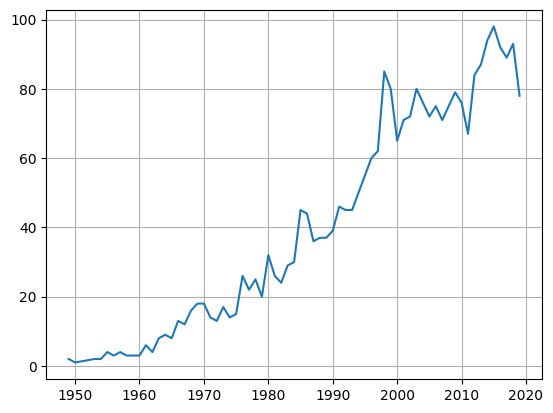

In [68]:
plt.plot(themes_per_year[:-2])
plt.grid(True)

### Line Charts with Two Seperate Axes

Text(0, 0.5, 'Number of Themes')

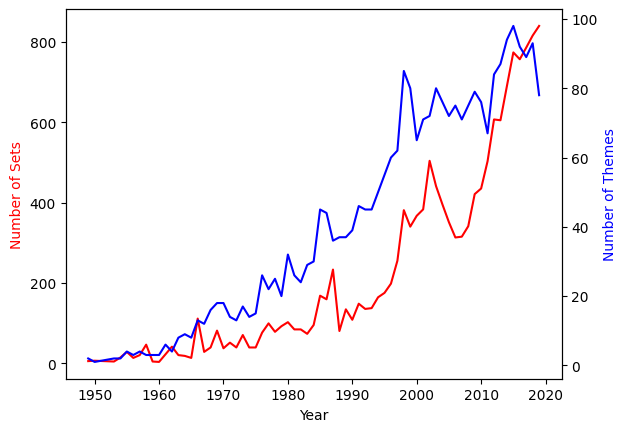

In [60]:
ax1 = plt.gca() # get current axis
ax2 = ax1.twinx()

ax1.plot(sets_by_year[:-2], color='red')
ax2.plot(themes_per_year[:-2], color='blue')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets', color='red')
ax2.set_ylabel('Number of Themes', color='blue')

How many parts did the average LEGO set released in 1954 compared to 2017?

In [63]:
parts_per_set = sets.groupby('year').agg({'num_parts': pd.Series.mean})
print(parts_per_set.head())

      num_parts
year           
1949  99.600000
1950   1.000000
1953  13.500000
1954  12.357143
1955  36.607143


In [64]:
print(parts_per_set.tail())

       num_parts
year            
2017  221.840967
2018  213.618873
2019  207.510714
2020  259.732938
2021    0.000000


### Scatter Plots in Matplotlib

Has the size and complexity of LEGO sets increased over time based on the number of parts? Do you spot a trend?

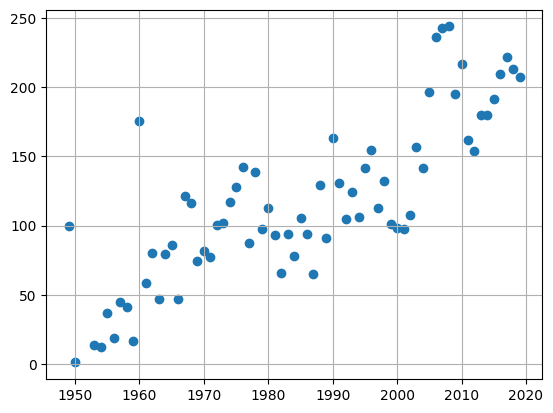

In [67]:
plt.scatter(parts_per_set.index[:-2], parts_per_set.num_parts[:-2])
plt.grid(True)

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets? 

In [76]:
set_theme_count = sets['theme_id'].value_counts()
set_theme_count.head()

theme_id
158    753
501    656
494    398
435    356
503    329
Name: count, dtype: int64


<img src="./assets/rebrickable_schema.png">

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv. 

In [71]:
themes = pd.read_csv('./data/themes.csv')
print(themes.head())
themes[themes.name == 'Star Wars']

   id            name  parent_id
0   1         Technic        NaN
1   2  Arctic Technic        1.0
2   3     Competition        1.0
3   4  Expert Builder        1.0
4   5           Model        1.0


,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


In [73]:
sets[sets.theme_id == 209]

,set_num,name,year,theme_id,num_parts
11013,75023-1,Star Wars Advent Calendar 2013,2013,209,254
11046,75056-1,Star Wars Advent Calendar 2014,2014,209,273
11080,75097-1,Star Wars Advent Calendar 2015,2015,209,291
11131,75146-1,Star Wars Advent Calendar 2016,2016,209,282
11173,75184-1,Star Wars Advent Calendar 2017,2017,209,309
11206,75213-1,Star Wars Advent Calendar 2018,2018,209,307
11245,75245-1,Star Wars Advent Calendar 2019,2019,209,280
11281,75279-1,Star Wars Advent Calendar 2020,2020,209,312
12019,7958-1,Star Wars Advent Calendar 2011,2011,209,267
14352,9509-1,Star Wars Advent Calendar 2012,2012,209,235


### Merging (i.e., Combining) DataFrames based on a Key


In [77]:
set_theme_count = pd.DataFrame({'id': set_theme_count.index,
                                'set_count': set_theme_count.values})

set_theme_count.head()

,id,set_count
0,158,753
1,501,656
2,494,398
3,435,356
4,503,329


In [79]:
merged_df = pd.merge(set_theme_count, themes, on='id')
merged_df.head()

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN
3,435,356,Ninjago,NaN
4,503,329,Key Chain,501.0


<BarContainer object of 10 artists>

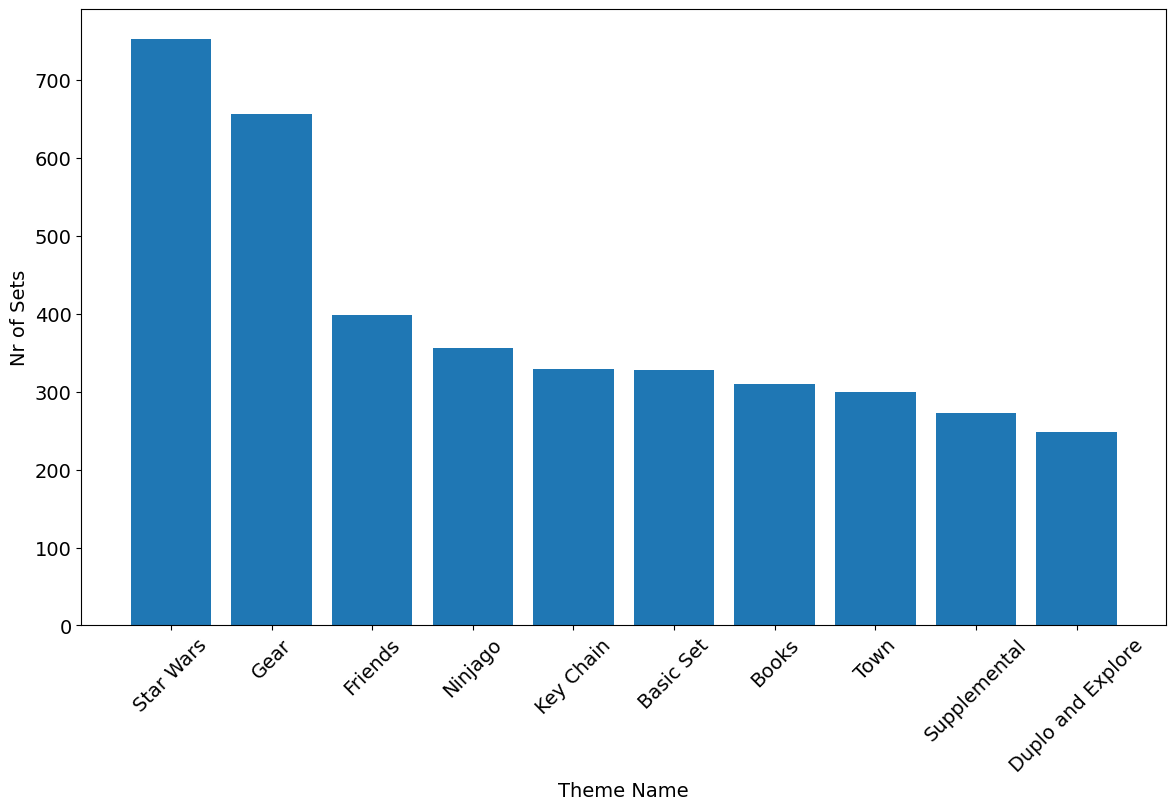

In [84]:
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14)
plt.ylabel('Nr of Sets', fontsize=14)
plt.xlabel('Theme Name', fontsize=14)
plt.bar(merged_df.name[:10], merged_df.set_count[:10])

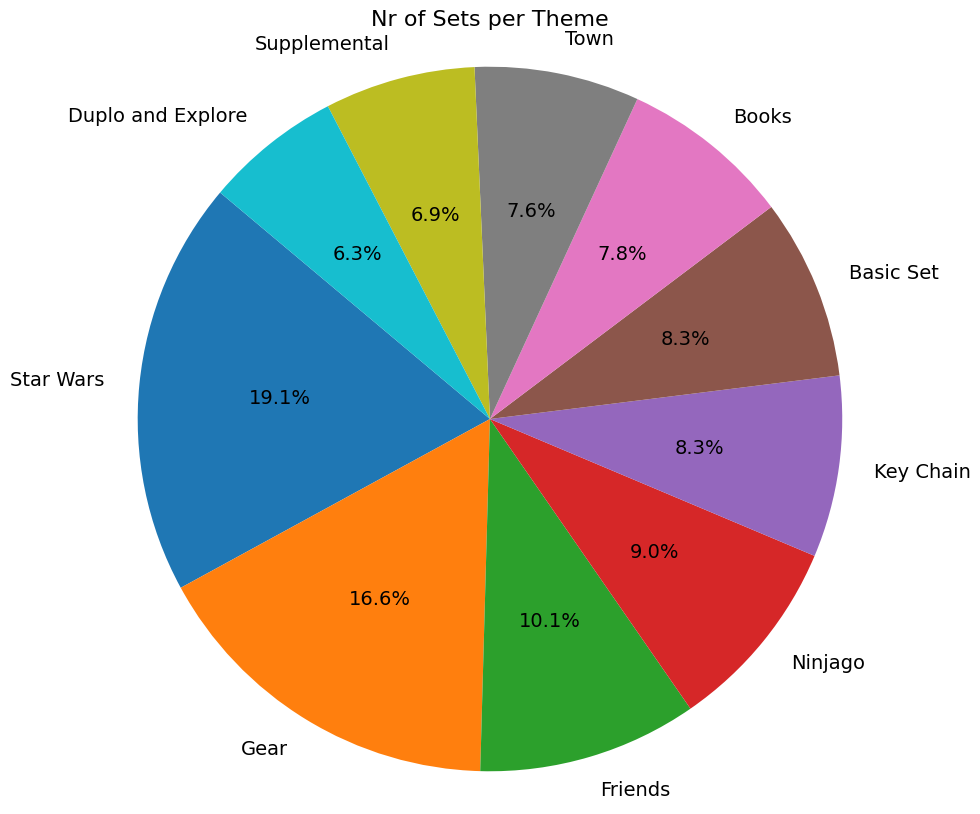

In [85]:
plt.figure(figsize=(10, 10))
plt.pie(merged_df.set_count[:10], labels=merged_df.name[:10], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 14})
plt.title('Nr of Sets per Theme', fontsize=16)
plt.axis('equal')  # Ensures the pie chart is a circle
plt.show()
